In [2]:
pip install pandas matplotlib seaborn scikit-learn numpy -q

Note: you may need to restart the kernel to use updated packages.


You should consider upgrading via the 'c:\Users\bilal\AppData\Local\Programs\Python\Python310\python.exe -m pip install --upgrade pip' command.


# Exploring customer 
 ## importing libraries

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os 
from pathlib import Path

In [4]:
os.chdir(Path.cwd().parent)

In [5]:
customer_csv_path = "../data/Customer.csv"

In [6]:
df = pd.read_csv(customer_csv_path)

In [7]:
df.head()

,Customer ID,Customer Name,Segment,Age,Country,City,State,Postal Code,Region
0,CG-12520,Claire Gute,Consumer,67,United States,Henderson,Kentucky,42420,South
1,DV-13045,Darrin Van Huff,Corporate,31,United States,Los Angeles,California,90036,West
2,SO-20335,Sean O'Donnell,Consumer,65,United States,Fort Lauderdale,Florida,33311,South
3,BH-11710,Brosina Hoffman,Consumer,20,United States,Los Angeles,California,90032,West
4,AA-10480,Andrew Allen,Consumer,50,United States,Concord,North Carolina,28027,South


In [8]:
df.columns

Index(['Customer ID', 'Customer Name', 'Segment', 'Age', 'Country', 'City',
       'State', 'Postal Code', 'Region'],
      dtype='object')

In [33]:
df.shape

(793, 4)

In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 793 entries, 0 to 792
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   Customer ID    793 non-null    object
 1   Customer Name  793 non-null    object
 2   Segment        793 non-null    object
 3   Age            793 non-null    int64 
 4   Country        793 non-null    object
 5   City           793 non-null    object
 6   State          793 non-null    object
 7   Postal Code    793 non-null    int64 
 8   Region         793 non-null    object
dtypes: int64(2), object(7)
memory usage: 55.9+ KB


In [10]:
print(f"Total Values in Country: {df.Country.nunique()}", end="\n\n")
print(f"Total Values in City: {df.City.nunique()}", end="\n\n")
print(f"Total Values in Region: {df.Region.nunique()}", end="\n\n")
print(f"Total Values in Segment: {df.Segment.nunique()}", end="\n\n")

Total Values in Country: 1

Total Values in City: 252

Total Values in Region: 4

Total Values in Segment: 3



In [11]:
print(f"Values in {df.Segment.value_counts()}")


Values in Segment
Consumer       409
Corporate      236
Home Office    148
Name: count, dtype: int64


### Predicting the segment so for the segment I assume that the best input features could be the reasion country city state and age, postal code could be but it's too many different every costomer has a own postal code so ahh nah not that, neither customer ID and Customer Name doesn't really add any significance to the model

~ After 15 minutes

### So after analyzing the columns a lil bit I realised that city and country column is not the best picks as
- city: too much data may cause overfitting
- country: just a single value ? USA ? lol

### So the final columns for training and evaluating the model are:
 State, Age, Region as input data (X)
 and we will be predicting the segment [Consumer, Corporate, Home Office] (Welp classification) and welp it's the y feature

In [12]:
df = df.drop(columns=['Customer ID', 'Customer Name','City', 'Country', 'Postal Code'])

In [13]:
df.describe()

,Age
count,793.000000
mean,44.467844
std,15.526673
min,18.000000
25%,31.000000
50%,45.000000
75%,58.000000
max,70.000000


In [14]:
df.isnull().sum()

Segment    0
Age        0
State      0
Region     0
dtype: int64

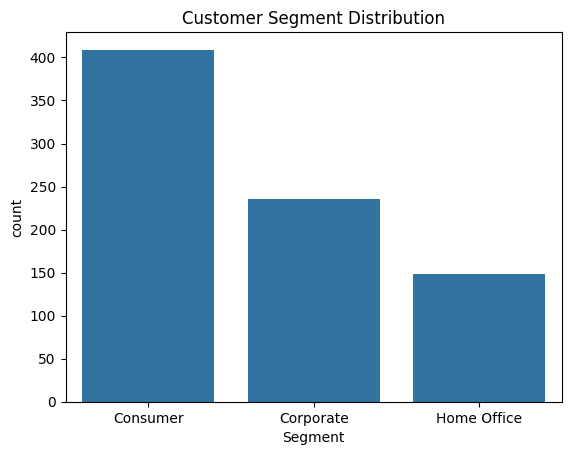

In [15]:
sns.countplot(x='Segment', data=df)
plt.title('Customer Segment Distribution')
plt.show()

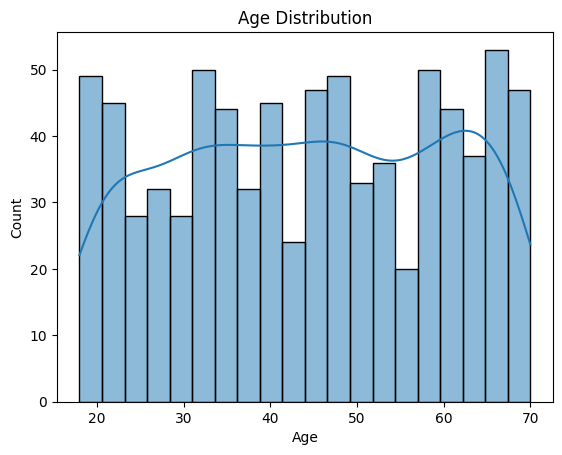

In [16]:
sns.histplot(df['Age'], bins=20, kde=True)
plt.title('Age Distribution')
plt.show()

In [17]:
df.Age.min()

np.int64(18)

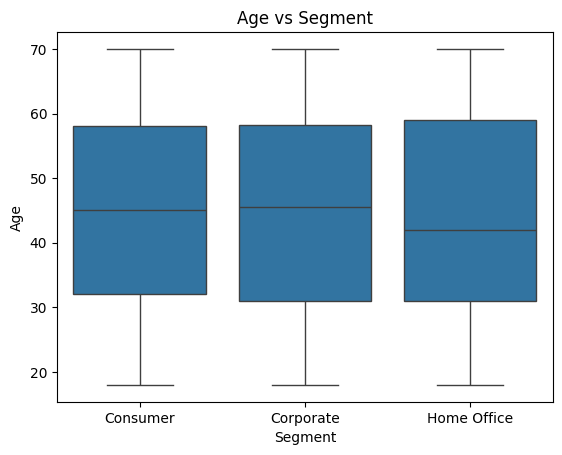

In [18]:
sns.boxplot(x='Segment', y='Age', data=df)
plt.title('Age vs Segment')
plt.show()

### Checking if certain regions lean toward certain segments

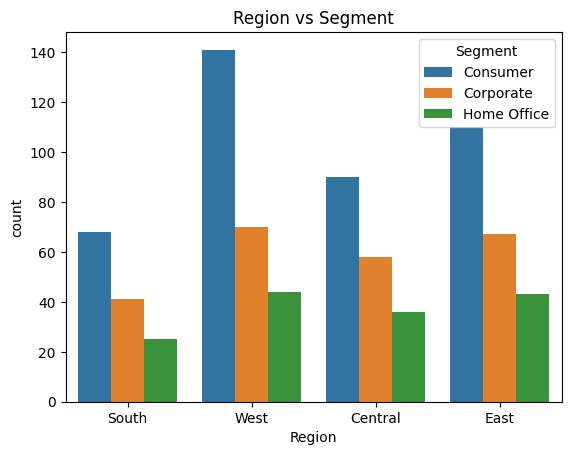

In [19]:
sns.countplot(x='Region', hue='Segment', data=df)
plt.title('Region vs Segment')
plt.show()

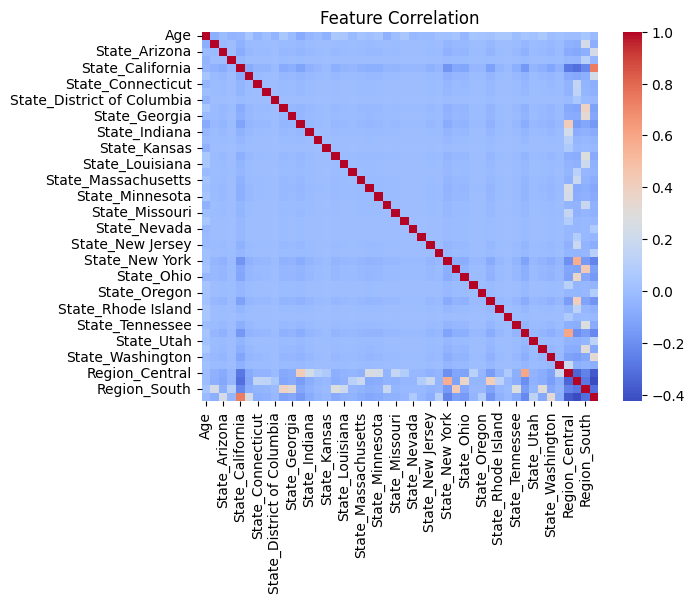

In [20]:
import pandas as pd

encoded = pd.get_dummies(df[['Age','State','Region']])
corr = encoded.corr()

sns.heatmap(corr, cmap='coolwarm')
plt.title('Feature Correlation')
plt.show()

In [21]:
state_counts = df['State'].value_counts()
rare_states = state_counts[state_counts < 10].index

df['State'] = df['State'].replace(rare_states, 'Other')

In [22]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

In [23]:
X = df.drop(columns=['Segment'])
y = df['Segment']

In [24]:
le = LabelEncoder()
y = le.fit_transform(df['Segment'])

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


In [36]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler


In [37]:
preprocess = ColumnTransformer([
    ("num", StandardScaler(), ["Age"]),
    ("cat", OneHotEncoder(handle_unknown="ignore"), ["State", "Region"])
])

In [38]:
pipe = Pipeline([
    ("prep", preprocess),
    ("clf", RandomForestClassifier(class_weight="balanced"))
])

In [39]:
# Cross Validation

from sklearn.model_selection import StratifiedKFold, cross_validate

SKF = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

scores = cross_validate(
    pipe, X, y, cv=SKF,
    scoring=['accuracy', 'balanced_accuracy', 'f1_macro'],
    return_train_score=True
)

scores

{'fit_time': array([0.27765179, 0.29907346, 0.28697658, 0.2576158 , 0.28079677]),
 'score_time': array([0.01578188, 0.01438546, 0.01300287, 0.01267719, 0.01537538]),
 'test_accuracy': array([0.34591195, 0.40251572, 0.35220126, 0.33544304, 0.32911392]),
 'train_accuracy': array([0.83596215, 0.83911672, 0.83911672, 0.84566929, 0.81417323]),
 'test_balanced_accuracy': array([0.30014415, 0.3498299 , 0.30024217, 0.30075038, 0.28311693]),
 'train_balanced_accuracy': array([0.85328492, 0.84799117, 0.84788065, 0.85341469, 0.84261323]),
 'test_f1_macro': array([0.29786756, 0.3474422 , 0.2959115 , 0.29815679, 0.28448442]),
 'train_f1_macro': array([0.82692767, 0.82730298, 0.82667611, 0.83412237, 0.80822868])}

In [41]:
from sklearn.dummy import DummyClassifier
dummy = DummyClassifier(strategy="most_frequent")
dummy_scores = cross_validate(dummy, X_train, y_train, cv=SKF, scoring='accuracy')
print(dummy_scores['test_score'].mean())  # will be ~0.516

0.5236720409948756


In [ ]:

X_train = pd.get_dummies(X_train, columns=['State','Region'], drop_first=True)
X_test = pd.get_dummies(X_test, columns=['State','Region'], drop_first=True)

X_train, X_test = X_train.align(X_test, join='left', axis=1, fill_value=0)

In [ ]:
# from sklearn.preprocessing import StandardScaler

# scaler = StandardScaler()
# X_train['Age'] = scaler.fit_transform(X_train[['Age']])
# X_test['Age'] = scaler.transform(X_test[['Age']])

In [27]:
LR = LogisticRegression(max_iter=1000, class_weight='balanced')
DTC = DecisionTreeClassifier(max_depth=5, class_weight='balanced')
RFC = RandomForestClassifier(n_estimators=100, class_weight='balanced')

In [28]:
df['Segment'].value_counts()

Segment
Consumer       409
Corporate      236
Home Office    148
Name: count, dtype: int64

In [29]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

models = {
    "Logistic Regression": LR,
    "Decision Tree": DTC,
    "Random Forest": RFC
}

for name, model in models.items():
    model.fit(X_train, y_train)
    pred = model.predict(X_test)

    print(f"\n{name}")
    print("Accuracy:", accuracy_score(y_test, pred))
    print("Confusion Matrix:\n", confusion_matrix(y_test, pred))
    print("Report:\n", classification_report(y_test, pred))


Logistic Regression
Accuracy: 0.34591194968553457
Confusion Matrix:
 [[29 24 24]
 [19 16 17]
 [11  9 10]]
Report:
               precision    recall  f1-score   support

           0       0.49      0.38      0.43        77
           1       0.33      0.31      0.32        52
           2       0.20      0.33      0.25        30

    accuracy                           0.35       159
   macro avg       0.34      0.34      0.33       159
weighted avg       0.38      0.35      0.36       159


Decision Tree
Accuracy: 0.3081761006289308
Confusion Matrix:
 [[15 38 24]
 [13 19 20]
 [ 7  8 15]]
Report:
               precision    recall  f1-score   support

           0       0.43      0.19      0.27        77
           1       0.29      0.37      0.32        52
           2       0.25      0.50      0.34        30

    accuracy                           0.31       159
   macro avg       0.33      0.35      0.31       159
weighted avg       0.35      0.31      0.30       159


Random Fores

In [30]:
import pandas as pd

importances = RFC.feature_importances_
feature_names = X_train.columns

feat_imp = pd.Series(importances, index=feature_names)
feat_imp = feat_imp.sort_values(ascending=False)

print(feat_imp.head(10))

Age                 0.809939
State_Other         0.016379
Region_West         0.014351
State_Illinois      0.012492
Region_East         0.011363
State_California    0.011311
Region_South        0.010751
State_Washington    0.009807
State_Texas         0.009135
State_Ohio          0.007979
dtype: float64


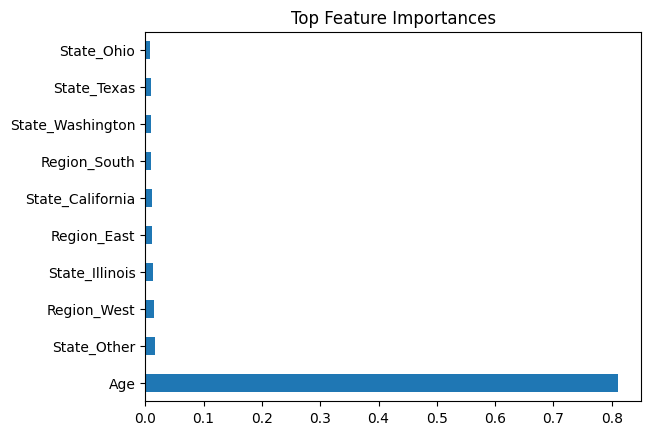

In [31]:
feat_imp.head(10).plot(kind='barh')
plt.title('Top Feature Importances')
plt.show()

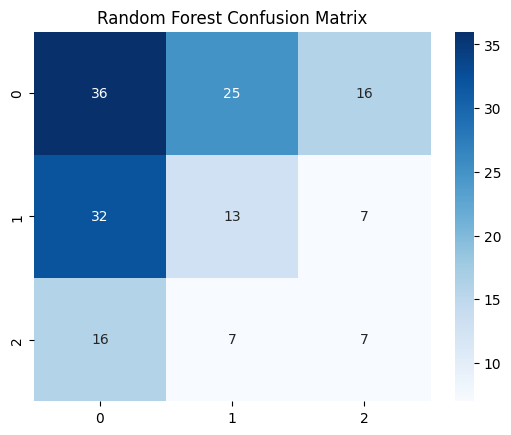

In [32]:
sns.heatmap(confusion_matrix(y_test, pred), annot=True, fmt='d', cmap='Blues')
plt.title(f'{name} Confusion Matrix')
plt.show()

### The model achieved moderate to low accuracy across all algorithms, with Random Forest performing slightly better. Feature importance analysis revealed that age was the dominant predictor, while geographic features contributed minimally. This indicates a weak relationship between the selected features and the target variable. The results highlight the importance of incorporating behavioral data, such as purchase history and transaction patterns, for effective customer segmentation.